In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
dataset = pd.read_csv("cement_customer_classification_1000.csv")

print("Dataset loaded successfully")
print("Rows:", dataset.shape[0])
print("Columns:", dataset.shape[1])

Dataset loaded successfully
Rows: 1000
Columns: 14


In [3]:
dataset.head()

,Customer_ID,Customer_Type,Region,Monthly_Quantity,Purchase_Frequency,Average_Order,Payment_Delay_Days,Credit_Limit,Relationship_Years,Previous_Month_Sales,Current_Month_Sales,Growth_Percentage,Complaint_Count,Customer_Category
0,C0001,Dealer,Trichy,278,7,42,14,395081,1,25000,22945,-8.22,3,Low Value
1,C0002,Retailer,Chennai,286,4,92,4,382898,4,25000,23578,-5.69,1,Low Value
2,C0003,Contractor,Dindigul,397,3,118,3,454918,1,39004,40724,4.41,3,Low Value
3,C0004,Contractor,Tirunelveli,551,8,69,10,480199,1,43263,47447,9.67,1,Regular
4,C0005,Dealer,Tirunelveli,744,3,253,3,810289,3,143057,162785,13.79,2,Regular


In [4]:
dataset.shape

(1000, 14)

In [5]:
print("Column Names:")
print(dataset.columns.tolist())

print("\nData Types:")
print(dataset.dtypes)

Column Names:
['Customer_ID', 'Customer_Type', 'Region', 'Monthly_Quantity', 'Purchase_Frequency', 'Average_Order', 'Payment_Delay_Days', 'Credit_Limit', 'Relationship_Years', 'Previous_Month_Sales', 'Current_Month_Sales', 'Growth_Percentage', 'Complaint_Count', 'Customer_Category']

Data Types:
Customer_ID                 str
Customer_Type               str
Region                      str
Monthly_Quantity          int64
Purchase_Frequency        int64
Average_Order             int64
Payment_Delay_Days        int64
Credit_Limit              int64
Relationship_Years        int64
Previous_Month_Sales      int64
Current_Month_Sales       int64
Growth_Percentage       float64
Complaint_Count           int64
Customer_Category           str
dtype: object


In [6]:
print("Missing Values:")
print(dataset.isnull().sum())

print("\nTotal Missing Values:", dataset.isnull().sum().sum())

print("\nDuplicate Rows:", dataset.duplicated().sum())

Missing Values:
Customer_ID             0
Customer_Type           0
Region                  0
Monthly_Quantity        0
Purchase_Frequency      0
Average_Order           0
Payment_Delay_Days      0
Credit_Limit            0
Relationship_Years      0
Previous_Month_Sales    0
Current_Month_Sales     0
Growth_Percentage       0
Complaint_Count         0
Customer_Category       0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 0


In [7]:
print("Missing Values:")
print(dataset.isnull().sum())

print("\nTotal Missing Values:", dataset.isnull().sum().sum())

print("\nDuplicate Rows:", dataset.duplicated().sum())

Missing Values:
Customer_ID             0
Customer_Type           0
Region                  0
Monthly_Quantity        0
Purchase_Frequency      0
Average_Order           0
Payment_Delay_Days      0
Credit_Limit            0
Relationship_Years      0
Previous_Month_Sales    0
Current_Month_Sales     0
Growth_Percentage       0
Complaint_Count         0
Customer_Category       0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 0


In [8]:
target_column = "Customer_Category"

X = dataset.drop(columns=[target_column, "Customer_ID"])
y = dataset[target_column]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nTarget Classes:")
print(y.unique())

Features (X):
['Customer_Type', 'Region', 'Monthly_Quantity', 'Purchase_Frequency', 'Average_Order', 'Payment_Delay_Days', 'Credit_Limit', 'Relationship_Years', 'Previous_Month_Sales', 'Current_Month_Sales', 'Growth_Percentage', 'Complaint_Count']

Target (y):
Customer_Category

Target Classes:
<ArrowStringArray>
['Low Value', 'Regular', 'High Value']
Length: 3, dtype: str


In [9]:
print("Customer Category Distribution:")
print(y.value_counts())

print("\nCustomer Category Percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Customer Category Distribution:
Customer_Category
Low Value     502
Regular       370
High Value    128
Name: count, dtype: int64

Customer Category Percentage:
Customer_Category
Low Value     50.2
Regular       37.0
High Value    12.8
Name: proportion, dtype: float64


In [10]:
categorical_columns = ["Customer_Type", "Region"]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Original Features:", X.shape[1])
print("Encoded Features:", X_encoded.shape[1])

print("\nEncoded Columns:")
print(X_encoded.columns.tolist())

Original Features: 12
Encoded Features: 19

Encoded Columns:
['Monthly_Quantity', 'Purchase_Frequency', 'Average_Order', 'Payment_Delay_Days', 'Credit_Limit', 'Relationship_Years', 'Previous_Month_Sales', 'Current_Month_Sales', 'Growth_Percentage', 'Complaint_Count', 'Customer_Type_Dealer', 'Customer_Type_Retailer', 'Region_Coimbatore', 'Region_Dindigul', 'Region_Erode', 'Region_Madurai', 'Region_Salem', 'Region_Tirunelveli', 'Region_Trichy']


In [11]:
target_mapping = {
    "Low Value": 0,
    "Regular": 1,
    "High Value": 2
}

y_encoded = y.map(target_mapping)

print("Target Mapping:")
print(target_mapping)

print("\nEncoded Target:")
print(y_encoded.head())

print("\nTarget Classes:")
print(y_encoded.unique())

Target Mapping:
{'Low Value': 0, 'Regular': 1, 'High Value': 2}

Encoded Target:
0    0
1    0
2    0
3    1
4    1
Name: Customer_Category, dtype: int64

Target Classes:
[0 1 2]


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training Data:
X_train: (800, 19)
y_train: (800,)

Testing Data:
X_test: (200, 19)
y_test: (200,)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling completed successfully
X_train_scaled shape: (800, 19)
X_test_scaled shape: (200, 19)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print("Logistic Regression Accuracy:",
      f"{logistic_accuracy:.2%}")

Logistic Regression Accuracy: 87.50%


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

decision_tree_pred = decision_tree_model.predict(X_test)

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_pred
)

print(
    "Decision Tree Accuracy:",
    f"{decision_tree_accuracy:.2%}"
)

Decision Tree Accuracy: 91.50%


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print(
    "KNN Accuracy:",
    f"{knn_accuracy:.2%}"
)

KNN Accuracy: 78.00%


In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print(
    "SVM Accuracy:",
    f"{svm_accuracy:.2%}"
)

SVM Accuracy: 84.00%


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_pred = random_forest_model.predict(X_test)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_pred
)

print(
    "Random Forest Accuracy:",
    f"{random_forest_accuracy:.2%}"
)

Random Forest Accuracy: 87.50%


In [19]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        random_forest_accuracy,
        decision_tree_accuracy,
        knn_accuracy,
        svm_accuracy
    ]
})

model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

model_comparison

,Model,Accuracy
2,Decision Tree,0.915
0,Logistic Regression,0.875
1,Random Forest,0.875
4,SVM,0.840
3,KNN,0.780


In [20]:
model_comparison["Accuracy (%)"] = (
    model_comparison["Accuracy"] * 100
).round(2)

model_comparison

,Model,Accuracy,Accuracy (%)
2,Decision Tree,0.915,91.5
0,Logistic Regression,0.875,87.5
1,Random Forest,0.875,87.5
4,SVM,0.840,84.0
3,KNN,0.780,78.0


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics for all models

logistic_precision = precision_score(
    y_test, logistic_pred, average="weighted"
)

logistic_recall = recall_score(
    y_test, logistic_pred, average="weighted"
)

logistic_f1 = f1_score(
    y_test, logistic_pred, average="weighted"
)


random_forest_precision = precision_score(
    y_test, random_forest_pred, average="weighted"
)

random_forest_recall = recall_score(
    y_test, random_forest_pred, average="weighted"
)

random_forest_f1 = f1_score(
    y_test, random_forest_pred, average="weighted"
)


decision_tree_precision = precision_score(
    y_test, decision_tree_pred, average="weighted"
)

decision_tree_recall = recall_score(
    y_test, decision_tree_pred, average="weighted"
)

decision_tree_f1 = f1_score(
    y_test, decision_tree_pred, average="weighted"
)


knn_precision = precision_score(
    y_test, knn_pred, average="weighted"
)

knn_recall = recall_score(
    y_test, knn_pred, average="weighted"
)

knn_f1 = f1_score(
    y_test, knn_pred, average="weighted"
)


svm_precision = precision_score(
    y_test, svm_pred, average="weighted"
)

svm_recall = recall_score(
    y_test, svm_pred, average="weighted"
)

svm_f1 = f1_score(
    y_test, svm_pred, average="weighted"
)


# Create comparison table

metrics_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "KNN",
        "SVM"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        random_forest_accuracy,
        decision_tree_accuracy,
        knn_accuracy,
        svm_accuracy
    ],
    
    "Precision": [
        logistic_precision,
        random_forest_precision,
        decision_tree_precision,
        knn_precision,
        svm_precision
    ],
    
    "Recall": [
        logistic_recall,
        random_forest_recall,
        decision_tree_recall,
        knn_recall,
        svm_recall
    ],
    
    "F1 Score": [
        logistic_f1,
        random_forest_f1,
        decision_tree_f1,
        knn_f1,
        svm_f1
    ]
})


# Convert to percentage

metrics_comparison[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = (
    metrics_comparison[
        ["Accuracy", "Precision", "Recall", "F1 Score"]
    ] * 100
).round(2)


metrics_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,87.5,87.86,87.5,87.52
1,Random Forest,87.5,87.45,87.5,87.33
2,Decision Tree,91.5,91.49,91.5,91.45
3,KNN,78.0,78.08,78.0,77.99
4,SVM,84.0,84.34,84.0,84.05


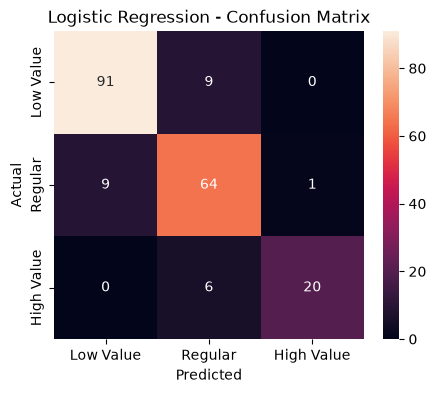

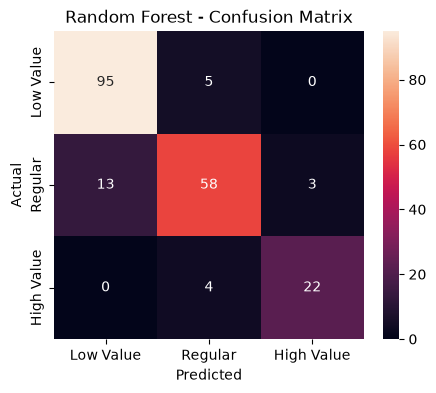

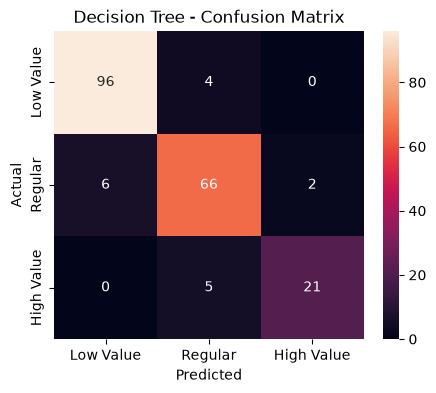

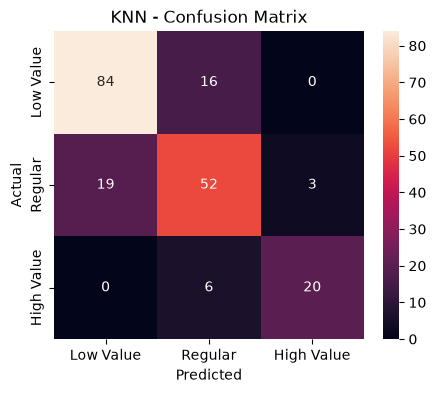

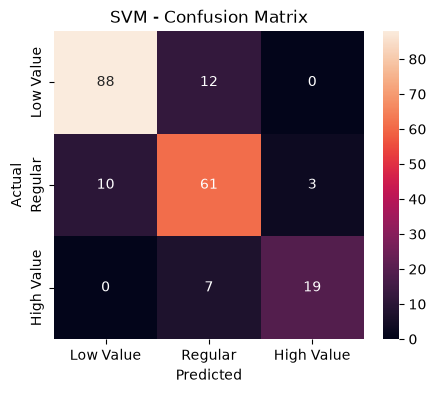

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Model predictions
predictions = {
    "Logistic Regression": logistic_pred,
    "Random Forest": random_forest_pred,
    "Decision Tree": decision_tree_pred,
    "KNN": knn_pred,
    "SVM": svm_pred
}

# Class names
class_names = [
    "Low Value",
    "Regular",
    "High Value"
]

# Plot confusion matrix for each model
for model_name, prediction in predictions.items():

    cm = confusion_matrix(
        y_test,
        prediction
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(model_name + " - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

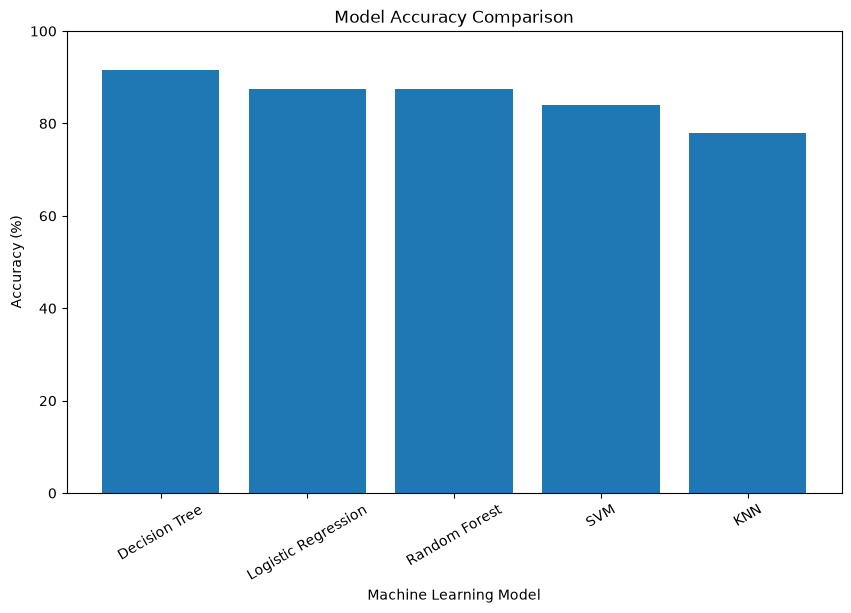

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy (%)"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=30)

plt.ylim(0, 100)

plt.show()

In [24]:
from sklearn.metrics import classification_report

print("Decision Tree - Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        decision_tree_pred,
        target_names=[
            "Low Value",
            "Regular",
            "High Value"
        ]
    )
)

Decision Tree - Classification Report
              precision    recall  f1-score   support

   Low Value       0.94      0.96      0.95       100
     Regular       0.88      0.89      0.89        74
  High Value       0.91      0.81      0.86        26

    accuracy                           0.92       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.91      0.92      0.91       200



In [25]:
tree_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        decision_tree_accuracy,
        random_forest_accuracy
    ],
    
    "Precision": [
        decision_tree_precision,
        random_forest_precision
    ],
    
    "Recall": [
        decision_tree_recall,
        random_forest_recall
    ],
    
    "F1 Score": [
        decision_tree_f1,
        random_forest_f1
    ]
})

tree_comparison[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = (
    tree_comparison[
        ["Accuracy", "Precision", "Recall", "F1 Score"]
    ] * 100
).round(2)

tree_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,91.5,91.49,91.5,91.45
1,Random Forest,87.5,87.45,87.5,87.33


In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Parameters to test
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid Search
grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

# Train
grid_dt.fit(X_train, y_train)

print("Best Parameters:")
print(grid_dt.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_dt.best_score_:.2%}")

Best Parameters:
{'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation F1 Score:
87.51%


In [27]:
# Get the best tuned Decision Tree
best_dt_model = grid_dt.best_estimator_

# Predict on test data
tuned_dt_pred = best_dt_model.predict(X_test)

# Test Accuracy
tuned_dt_accuracy = accuracy_score(
    y_test,
    tuned_dt_pred
)

print(
    "Tuned Decision Tree Accuracy:",
    f"{tuned_dt_accuracy:.2%}"
)


# Classification Report
print("\nTuned Decision Tree Classification Report")
print("=" * 55)

print(
    classification_report(
        y_test,
        tuned_dt_pred,
        target_names=[
            "Low Value",
            "Regular",
            "High Value"
        ]
    )
)

Tuned Decision Tree Accuracy: 92.50%

Tuned Decision Tree Classification Report
              precision    recall  f1-score   support

   Low Value       0.98      0.96      0.97       100
     Regular       0.89      0.91      0.90        74
  High Value       0.81      0.85      0.83        26

    accuracy                           0.93       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.93      0.93      0.93       200



In [28]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "Tuned Decision Tree",
        "KNN",
        "SVM"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        random_forest_accuracy,
        decision_tree_accuracy,
        tuned_dt_accuracy,
        knn_accuracy,
        svm_accuracy
    ]
})

final_comparison["Accuracy (%)"] = (
    final_comparison["Accuracy"] * 100
).round(2)

final_comparison = final_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

final_comparison[
    ["Model", "Accuracy (%)"]
]

,Model,Accuracy (%)
3,Tuned Decision Tree,92.5
2,Decision Tree,91.5
1,Random Forest,87.5
0,Logistic Regression,87.5
5,SVM,84.0
4,KNN,78.0


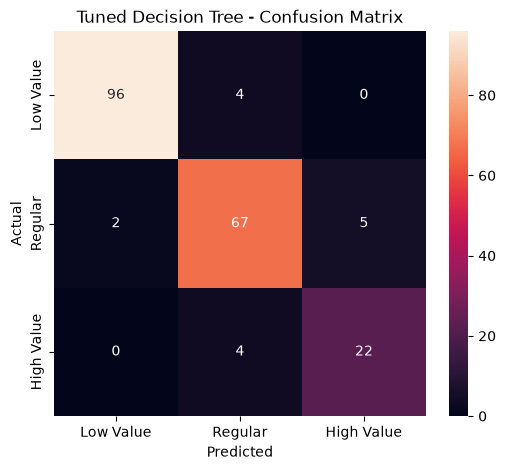

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(
    y_test,
    tuned_dt_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    xticklabels=[
        "Low Value",
        "Regular",
        "High Value"
    ],
    yticklabels=[
        "Low Value",
        "Regular",
        "High Value"
    ]
)

plt.title("Tuned Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Monthly_Quantity,0.484582
8,Growth_Percentage,0.175688
1,Purchase_Frequency,0.111797
3,Payment_Delay_Days,0.105080
5,Relationship_Years,0.055225
4,Credit_Limit,0.023623
7,Current_Month_Sales,0.021490
2,Average_Order,0.007392
6,Previous_Month_Sales,0.006789
16,Region_Salem,0.005315


In [31]:
top_features = feature_importance.head(10)

top_features

,Feature,Importance
0,Monthly_Quantity,0.484582
8,Growth_Percentage,0.175688
1,Purchase_Frequency,0.111797
3,Payment_Delay_Days,0.105080
5,Relationship_Years,0.055225
4,Credit_Limit,0.023623
7,Current_Month_Sales,0.021490
2,Average_Order,0.007392
6,Previous_Month_Sales,0.006789
16,Region_Salem,0.005315


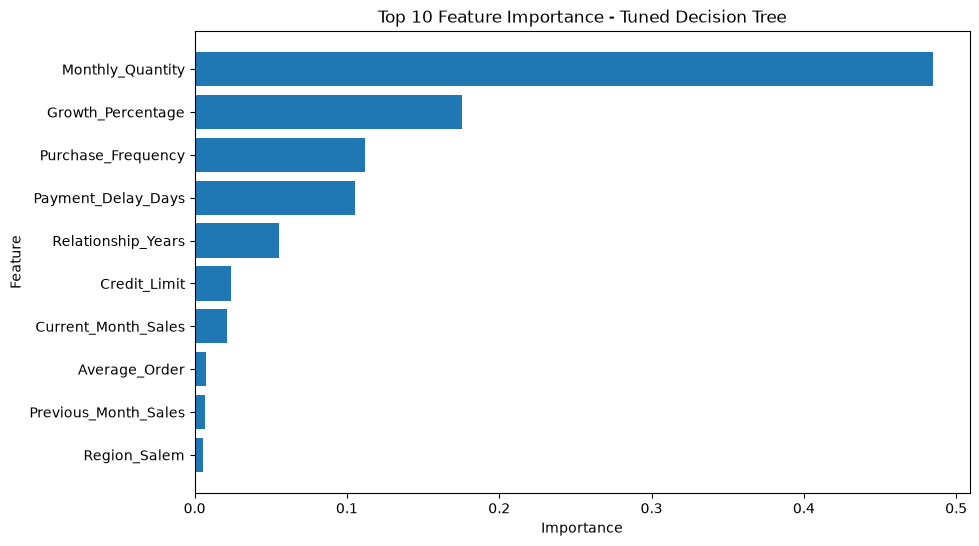

In [32]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Feature Importance - Tuned Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [33]:
import pickle

with open("cement_customer_final_model.pkl", "wb") as file:
    pickle.dump(best_dt_model, file)

with open("cement_customer_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Final model saved successfully")
print("Scaler saved successfully")

Final model saved successfully
Scaler saved successfully


In [34]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in Current Folder:")
print(os.listdir())

Current Folder:
C:\HOPE AI\AI TAMIL COURSE\Cement Customer Classification

Files in Current Folder:
['.ipynb_checkpoints', '.venv', 'app.py', 'cement customer classfication .ipynb', 'cement_customer_classification.ipynb', 'cement_customer_classification_1000.csv', 'cement_customer_final_model.pkl', 'cement_customer_model.pkl', 'cement_customer_scaler.pkl']


In [35]:
feature_columns = X_train.columns.tolist()

with open("cement_customer_feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)

print("Feature columns saved successfully")
print("Number of features:", len(feature_columns))
print("\nFeature columns:")
print(feature_columns)

Feature columns saved successfully
Number of features: 19

Feature columns:
['Monthly_Quantity', 'Purchase_Frequency', 'Average_Order', 'Payment_Delay_Days', 'Credit_Limit', 'Relationship_Years', 'Previous_Month_Sales', 'Current_Month_Sales', 'Growth_Percentage', 'Complaint_Count', 'Customer_Type_Dealer', 'Customer_Type_Retailer', 'Region_Coimbatore', 'Region_Dindigul', 'Region_Erode', 'Region_Madurai', 'Region_Salem', 'Region_Tirunelveli', 'Region_Trichy']


In [36]:
# Create one sample customer

sample_customer = pd.DataFrame({
    "Monthly_Quantity": [500],
    "Purchase_Frequency": [15],
    "Average_Order": [30],
    "Payment_Delay_Days": [5],
    "Credit_Limit": [100000],
    "Relationship_Years": [10],
    "Previous_Month_Sales": [150000],
    "Current_Month_Sales": [170000],
    "Growth_Percentage": [13.33],
    "Complaint_Count": [1],
    "Customer_Type_Dealer": [1],
    "Customer_Type_Retailer": [0],
    "Region_Coimbatore": [0],
    "Region_Dindigul": [0],
    "Region_Erode": [0],
    "Region_Madurai": [0],
    "Region_Salem": [0],
    "Region_Tirunelveli": [0],
    "Region_Trichy": [0]
})


# Make sure column order is exactly the same
sample_customer = sample_customer[feature_columns]


# Prediction
sample_prediction = best_dt_model.predict(sample_customer)[0]


# Convert number back to category
reverse_mapping = {
    0: "Low Value",
    1: "Regular",
    2: "High Value"
}


predicted_category = reverse_mapping[sample_prediction]


print("Predicted Customer Category:")
print(predicted_category)

Predicted Customer Category:
High Value


In [37]:
prediction_probabilities = best_dt_model.predict_proba(
    sample_customer
)[0]

probability_table = pd.DataFrame({
    "Customer Category": [
        "Low Value",
        "Regular",
        "High Value"
    ],
    "Probability (%)": (
        prediction_probabilities * 100
    ).round(2)
})

probability_table

,Customer Category,Probability (%)
0,Low Value,0.0
1,Regular,0.0
2,High Value,100.0


In [38]:
import pickle

# Save final tuned model
with open("cement_customer_final_model.pkl", "wb") as file:
    pickle.dump(best_dt_model, file)

# Save feature columns
with open("cement_customer_feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)

print("Final tuned model saved successfully")
print("Feature columns saved successfully")

Final tuned model saved successfully
Feature columns saved successfully


In [39]:
import pickle
import pandas as pd

# Load the exact model used by Streamlit
with open("cement_customer_final_model.pkl", "rb") as file:
    test_model = pickle.load(file)

with open("cement_customer_feature_columns.pkl", "rb") as file:
    test_features = pickle.load(file)


# Same values used in Streamlit
streamlit_test = pd.DataFrame({
    "Monthly_Quantity": [500],
    "Purchase_Frequency": [15],
    "Average_Order": [30],
    "Payment_Delay_Days": [5],
    "Credit_Limit": [100000],
    "Relationship_Years": [10],
    "Previous_Month_Sales": [150000],
    "Current_Month_Sales": [170000],
    "Growth_Percentage": [13.33],
    "Complaint_Count": [1],
    "Customer_Type_Dealer": [1],
    "Customer_Type_Retailer": [0],
    "Region_Coimbatore": [1],
    "Region_Dindigul": [0],
    "Region_Erode": [0],
    "Region_Madurai": [0],
    "Region_Salem": [0],
    "Region_Tirunelveli": [0],
    "Region_Trichy": [0]
})


# Exact feature order
streamlit_test = streamlit_test[test_features]


# Prediction
test_prediction = test_model.predict(streamlit_test)[0]

reverse_mapping = {
    0: "Low Value",
    1: "Regular",
    2: "High Value"
}

print("Prediction using saved Streamlit model:")
print(reverse_mapping[test_prediction])

Prediction using saved Streamlit model:
High Value


In [40]:
# Take 3 actual customers from the test dataset

actual_test_data = X_test.head(3)

actual_predictions = best_dt_model.predict(
    actual_test_data
)

print("Actual values:")
print(y_test.head(3).values)

print("\nPredicted values:")
print(actual_predictions)

Actual values:
[1 0 2]

Predicted values:
[1 1 2]


In [41]:
print("Actual vs Predicted")

for actual, predicted in zip(
    y_test.head(10),
    best_dt_model.predict(X_test.head(10))
):
    print(
        "Actual:",
        actual,
        " | Predicted:",
        predicted
    )

Actual vs Predicted
Actual: 1  | Predicted: 1
Actual: 0  | Predicted: 1
Actual: 2  | Predicted: 2
Actual: 1  | Predicted: 1
Actual: 2  | Predicted: 1
Actual: 1  | Predicted: 1
Actual: 0  | Predicted: 1
Actual: 1  | Predicted: 1
Actual: 2  | Predicted: 1
Actual: 1  | Predicted: 1


In [42]:
from sklearn.metrics import confusion_matrix

full_pred = best_dt_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    full_pred
)

print("Full Test Set Confusion Matrix:")
print(cm)

print("\nTotal Test Samples:", len(y_test))
print("Correct Predictions:", (y_test == full_pred).sum())
print("Wrong Predictions:", (y_test != full_pred).sum())

Full Test Set Confusion Matrix:
[[96  4  0]
 [ 2 67  5]
 [ 0  4 22]]

Total Test Samples: 200
Correct Predictions: 185
Wrong Predictions: 15


In [43]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "Tuned Decision Tree",
        "KNN",
        "SVM"
    ],

    "Accuracy (%)": [
        87.50,
        87.50,
        91.50,
        92.50,
        78.00,
        84.00
    ]
})

final_results = final_results.sort_values(
    by="Accuracy (%)",
    ascending=False
)

final_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Final model comparison saved successfully")
print()
print(final_results)

Final model comparison saved successfully

                 Model  Accuracy (%)
3  Tuned Decision Tree          92.5
2        Decision Tree          91.5
1        Random Forest          87.5
0  Logistic Regression          87.5
5                  SVM          84.0
4                  KNN          78.0


In [44]:
import os

print("FINAL PROJECT FILES")
print("=" * 50)

for file in os.listdir():
    print(file)

FINAL PROJECT FILES
.ipynb_checkpoints
.venv
app.py
cement_customer_classification.ipynb
cement_customer_classification_1000.csv
cement_customer_feature_columns.pkl
cement_customer_final_model.pkl
cement_customer_model.pkl
cement_customer_scaler.pkl
model_comparison_results.csv
